In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
sortS100 = "./BRONZE/long_run_filter100/rnadist/dist_100/"
FIGURE_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/figures/"
# familias
fams = ['23s', 'telomerase', '16s', '5s', 'grp1', 'srp', 'RNaseP', 'tmRNA', 'tRNA']

def read_dfs(BASE_PATH, output_base=None, label="sortS100"):
    epochs = [n*5 for n in range(1,11)]
    dfs = { f: [] for f in fams }

    for f in fams:
        for i, ep in enumerate(epochs):
            path = os.path.join(BASE_PATH, f"{ep}_epoch", f)
            
            train = pd.read_csv(os.path.join(path, "train_log.csv"))
            if i > 0:
                train["epoch"] += epochs[i-1]
            test = pd.read_csv(os.path.join(path, "test.csv"))

            # insertar métricas de test en la última fila de train
            train.loc[train.index[-1], "f1"] = test["f1"].values[0]
            train.loc[train.index[-1], "f1_post"] = test["f1_post"].values[0]
            dfs[f].append(train)

        dfs[f] = pd.concat(dfs[f], ignore_index=True)

        # guardar si hay carpeta de salida
        if output_base is not None:
            out_dir = os.path.join(output_base, label, f)
            os.makedirs(out_dir, exist_ok=True)
            out_file = os.path.join(out_dir, "metrics_table.csv") 
            # print(f"Guardado: {out_file}")

    return dfs

In [37]:
paths = {
    "sortS400": "./BRONZE/long_run_filter100/rnadist/dist_400/",
    "sortS200": "./BRONZE/long_run_filter100/rnadist/dist_200/",
    "sortS100": "./BRONZE/long_run_filter100/rnadist/dist_100/",
    "clus400": "./BRONZE/long_run_filter100/herarchical_cluster/dist_400/",
    "clusS200": "./BRONZE/long_run_filter100/herarchical_cluster/dist_200/",
    "clusS100": "./BRONZE/long_run_filter100/herarchical_cluster/dist_100/",
    "randS400": "./BRONZE/long_run_filter100/samples/dist_400/",
    "randS200": "./BRONZE/long_run_filter100/samples/dist_200/",
    "randS100": "./BRONZE/long_run_filter100/samples/dist_100/",
    "baseline": "./BRONZE/long_run_filter100/famfold/"
}
 

In [38]:

def filter_dfs(dfs, max_epoch=25):
    out = {}
    for fam, df in dfs.items():
        # por si 'epoch' viene como string en algún caso
        df2 = df.copy()
        df2['epoch'] = pd.to_numeric(df2['epoch'], errors='coerce')
        out[fam] = df2.loc[df2['epoch'] <= max_epoch].copy()
    return out

# leer ambos sets
dfs_all = {k: read_dfs(v) for k, v in paths.items()}

dfs1 = dfs_all["baseline"]
dfs2 = dfs_all["sortS100"]
dfs3 = dfs_all["sortS200"]
dfs4 = dfs_all["sortS400"]

# SETUP PLOT

In [39]:

def smooth_curve(y, window=5):
    return y.rolling(window=window, center=True, min_periods=1).mean()

def plot_loss_across_datasets(datasets, dataset_names, fams, figsize=(5, 4), dist_plot=False, smooth=True):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["sortS100", "baseline"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(sortS100)
    dfs2 = read_dfs(baseline)
    plot_f1_across_datasets([dfs1, dfs2], ["sortS100", "baseline"], fams)
    """
    
    n_fams = len(fams)
    cols = n_fams
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 
            
            if smooth:
                ax.plot(df['epoch'], smooth_curve(df['train_loss']), label=f'{name}',
                        color=color, linewidth=1,)
                ax.plot(df['epoch'], smooth_curve(df['valid_loss']), label=None,
                        color=color, linewidth=2, linestyle="--")
            else:
                ax.plot(df['epoch'], df['train_loss'], label=f'{name}',
                        color=color, linewidth=1, )
                
                ax.plot(df['epoch'], df['valid_loss'], label=None
                        ,color=color, linewidth=2,linestyle="--" )
 

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 0.11)
        ax.set_xlim(0, 25)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('Loss')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Leyenda solo en el último eje visible
    axes[-1].legend(title="Loss",loc="upper right", fontsize=10)

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Comparación de train y valid loss entre datasets", fontsize=16)
    fig.tight_layout()
    plt.show()


def plot_valid_f1_across_datasets(datasets, dataset_names, fams, figsize=(5, 4), dist_plot=False, save=False):
    """
    Grafica comparaciones de F1 (train y test) entre múltiples datasets.

    Parámetros
    ----------
    datasets : list
        Lista de diccionarios {fam_name: DataFrame}, por ejemplo [dfs1, dfs2, dfs3].
    dataset_names : list
        Lista con nombres descriptivos (mismo orden que datasets), por ejemplo ["sortS100", "baseline"].
    fams : list
        Lista de nombres de familias a graficar (claves comunes a todos los datasets).
    cols : int, opcional
        Cantidad de columnas en la grilla de plots.
    figsize : tuple, opcional
        Tamaño base (ancho, alto) de cada subplot en pulgadas.

    Ejemplo
    --------
    dfs1 = read_dfs(sortS100)
    dfs2 = read_dfs(baseline)
    plot_f1_across_datasets([dfs1, dfs2], ["sortS100", "baseline"], fams)
    """
    
    n_fams = len(fams)
    cols = n_fams
    rows = (n_fams + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1]*rows),
                             constrained_layout=True, sharex=True, sharey=True)
    axes = axes.flatten()

    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    for ax, fam in zip(axes, fams):
        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]

            color = base_colors[i % len(base_colors)] 

            ax.plot(df['epoch'], smooth_curve(df['valid_f1_post']), label=f'F1 ({name})',
                    color=color, linewidth=2, linestyle="--")
            # Test F1 post
            test_rows = df['f1_post'].notna()
            ax.scatter(df.loc[test_rows, 'epoch'], df.loc[test_rows, 'f1_post'],
                       color=color, s=50, marker='o' if i == 0 else 'x',
                       label=None)

        ax.set_title(f'{fam}', fontsize=12)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 25)
        ax.grid(True)

    # Ejes
    for n in range(0, len(axes), cols):
        axes[n].set_ylabel('F1 Score')
    for n in range(len(axes) - cols, len(axes)):
        axes[n].set_xlabel('Epoch')

    # Ocultar sobrantes
    for ax in axes[n_fams:]:
        ax.set_visible(False)

    fig.suptitle("Valid and test F1 - sincFold", fontsize=16)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_PATH + "sincfold_valid_F1_lr.pdf", dpi=300)
    plt.show()

/tmp/ipykernel_331833/3630678216.py:79: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


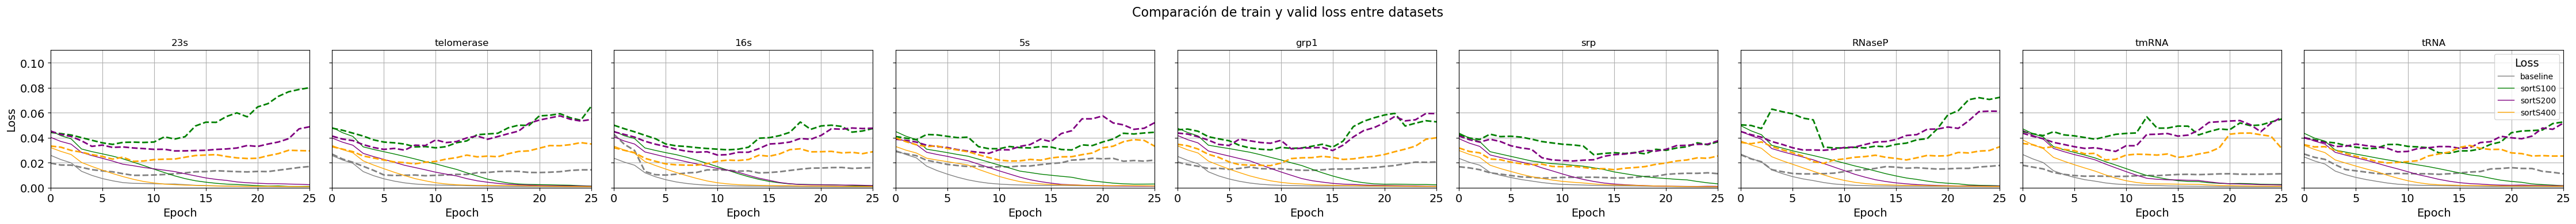

/tmp/ipykernel_331833/3630678216.py:150: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


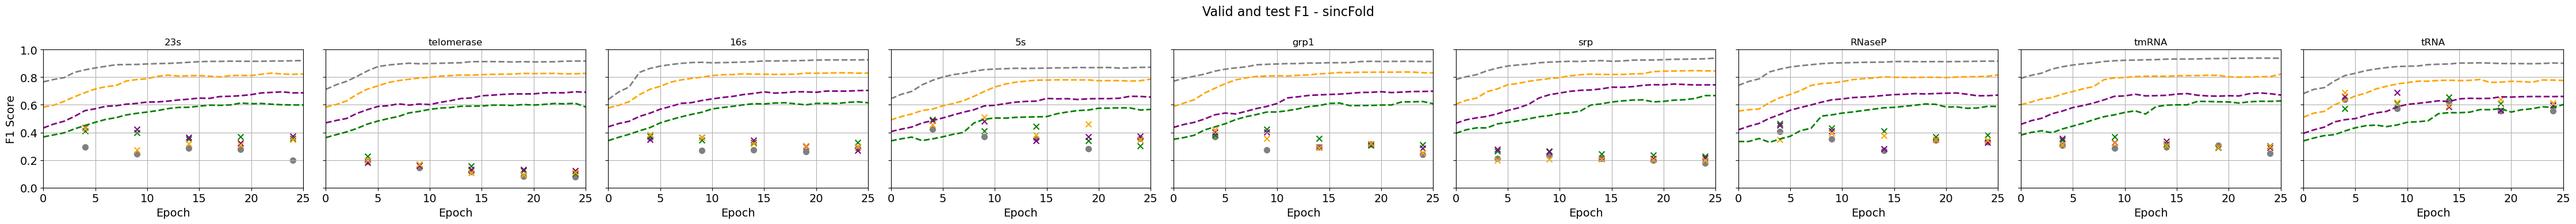

In [40]:
dataset_names = ["baseline","sortS100", "sortS200", "sortS400"]
df_list = [dfs_all[k] for k in dataset_names]
 

plot_loss_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
)


plot_valid_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams
)

In [41]:
def plot_loss_and_f1_across_datasets(
    datasets, dataset_names, fams, title="Train/Valid Loss and Valid/Test F1 by family", 
    figsize=(5, 4), dist_plot=False, smooth=True, save=False
):
    """
    Grafica comparaciones de:
       - Fila 1: train_loss y valid_loss
       - Fila 2: valid_f1_post + test_f1_post
    para múltiples datasets y múltiples familias.

    datasets: lista de dicts { fam_name: DataFrame }
    dataset_names: nombres de cada dataset
    fams: lista de familias a graficar
    """
    plt.rcParams.update({'font.size': 14})
    n_fams = len(fams)
    rows, cols = 2, n_fams

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(figsize[0] * cols, figsize[1] * rows),
        constrained_layout=True,
        sharex=True,
        sharey="row"
    ) 
    # paleta consistente
    if dist_plot:
        base_colors = ['gray', 'brown', 'blue', "#42f084"]
    else:
        base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']

    # ======== RECORRER FAMILIAS (columnas) ============
    for col, fam in enumerate(fams):

        # --- Fila 0: Loss ---
        ax_loss = axes[0, col]

        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]
            color = base_colors[i % len(base_colors)]

            if smooth:
                ax_loss.plot(df['epoch'], smooth_curve(df['train_loss']),
                             label=name, color=color, linewidth=1)
                ax_loss.plot(df['epoch'], smooth_curve(df['valid_loss']),
                             color=color, linewidth=2, linestyle="--")
            else:
                ax_loss.plot(df['epoch'], df['train_loss'],
                             label=name, color=color, linewidth=1)
                ax_loss.plot(df['epoch'], df['valid_loss'],
                             color=color, linewidth=2, linestyle="--")

        ax_loss.set_title(fam, fontsize=20, fontweight='bold')
        ax_loss.set_ylim(0, 0.11)
        ax_loss.set_xlim(0, 25)
        ax_loss.grid(False)


        # --- Fila 1: Valid + Test F1 ---
        ax_f1 = axes[1, col]

        for i, (dfs, name) in enumerate(zip(datasets, dataset_names)):
            df = dfs[fam]
            color = base_colors[i % len(base_colors)]

            # valid f1
            # ax_f1.plot(df['epoch'], df['valid_f1_post'],
            ax_f1.plot(df['epoch'], smooth_curve(df['valid_f1_post']),
                       color=color, linewidth=2, linestyle="--",
                       label=f"F1 ({name})")
            
 

            # test f1 points
            test_rows = df['f1_post'].notna()
            ax_f1.scatter(
                df.loc[test_rows, 'epoch'],
                df.loc[test_rows, 'f1_post'],
                color=color, s=50,
                marker='o' if i == 0 else 'x',
                label=None
            )

        ax_f1.set_ylim(0, 1)
        ax_f1.set_xlim(0, 25)
        ax_f1.set_xlabel("Epoch", fontsize=16)
        ax_f1.grid(False)

        if col == 0:
            ax_loss.set_ylabel("Loss", fontsize=18)
            ax_f1.set_ylabel("F1 Score", fontsize=18)

        ax_f1.set_xlabel("Epoch")

    # ======== Leyenda general solo una vez ============
    handles, labels = axes[0, -1].get_legend_handles_labels()
    axes[0, -1].legend(handles, labels, loc="upper right") #, ncol=len(dataset_names)

    fig.suptitle(title, fontsize=24)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        fig.savefig("loss_f1_comparison.pdf", dpi=300)

    plt.show()


/tmp/ipykernel_331833/2509083565.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


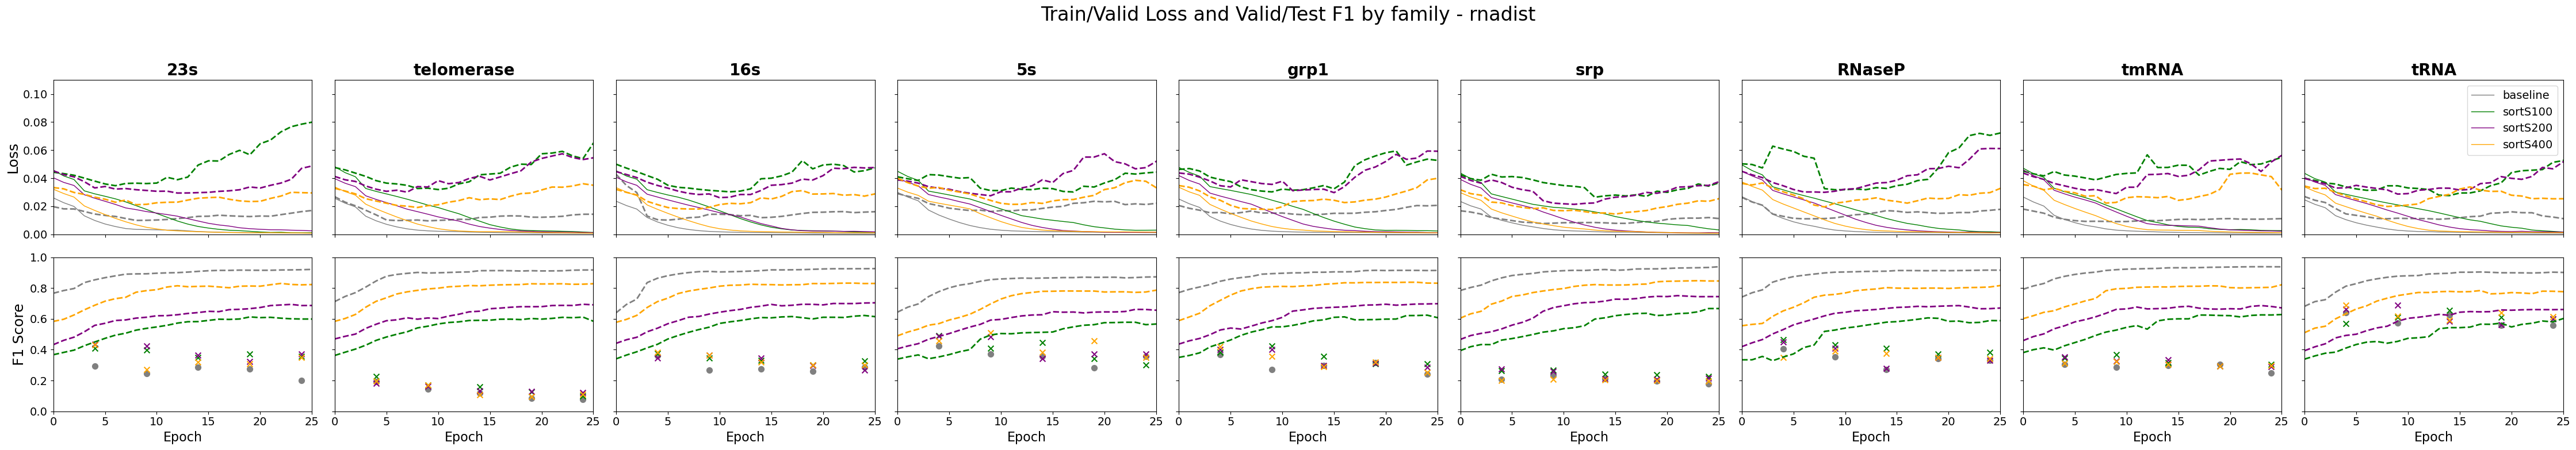

In [42]:
dataset_names = ["baseline","sortS100", "sortS200", "sortS400"]
df_list = [dfs_all[k] for k in dataset_names]

plot_loss_and_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
    title="Train/Valid Loss and Valid/Test F1 by family - rnadist",
)

/tmp/ipykernel_331833/2509083565.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


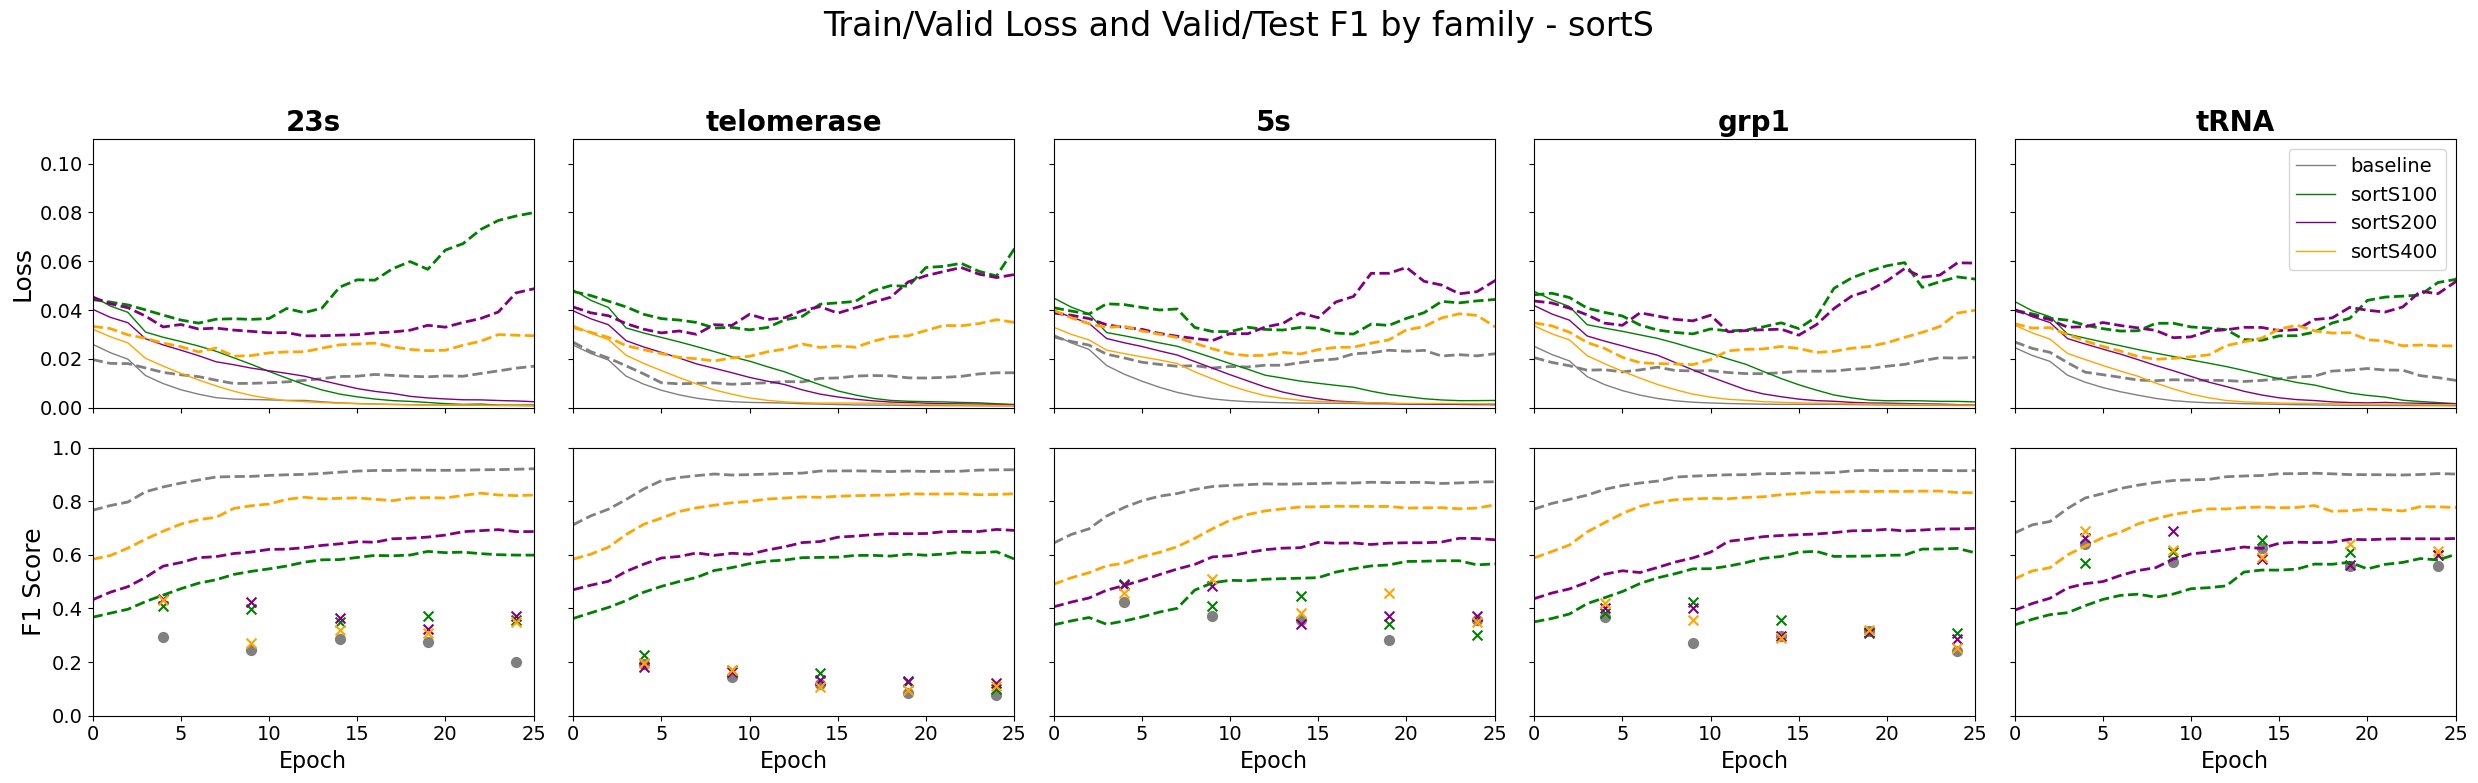

In [48]:
dataset_names = ["baseline","sortS100", "sortS200", "sortS400"]
df_list = [dfs_all[k] for k in dataset_names]
fams2 = ['23s', 'telomerase', '5s', 'grp1', 'tRNA']
plot_loss_and_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams2,
    title="Train/Valid Loss and Valid/Test F1 by family - sortS",
)

/tmp/ipykernel_331833/2509083565.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


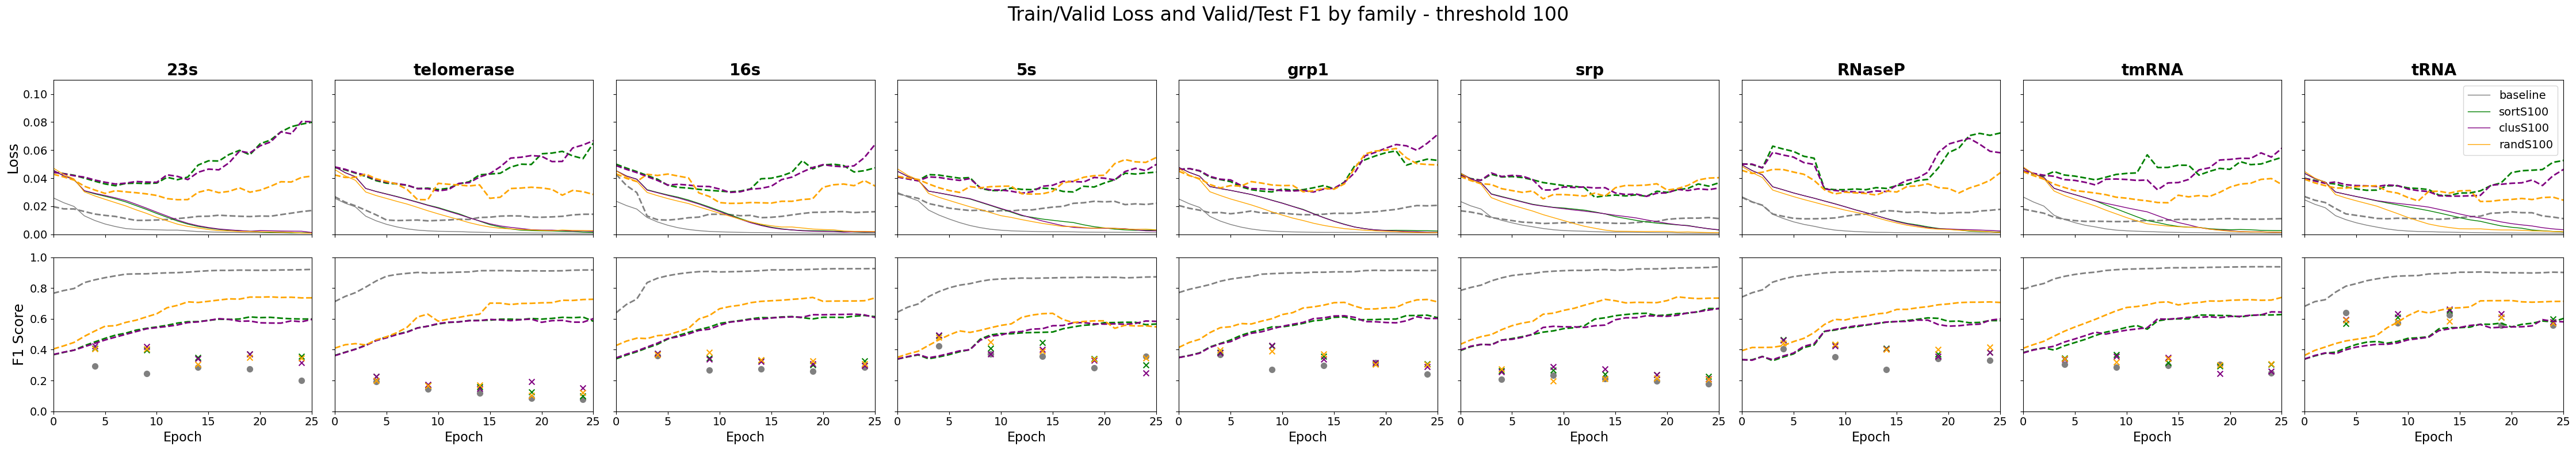

In [44]:
dataset_names = ["baseline", "sortS100", "clusS100", "randS100"]
df_list = [dfs_all[k] for k in dataset_names]
 
plot_loss_and_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams,
    title="Train/Valid Loss and Valid/Test F1 by family - threshold 100",
)

/tmp/ipykernel_331833/2509083565.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


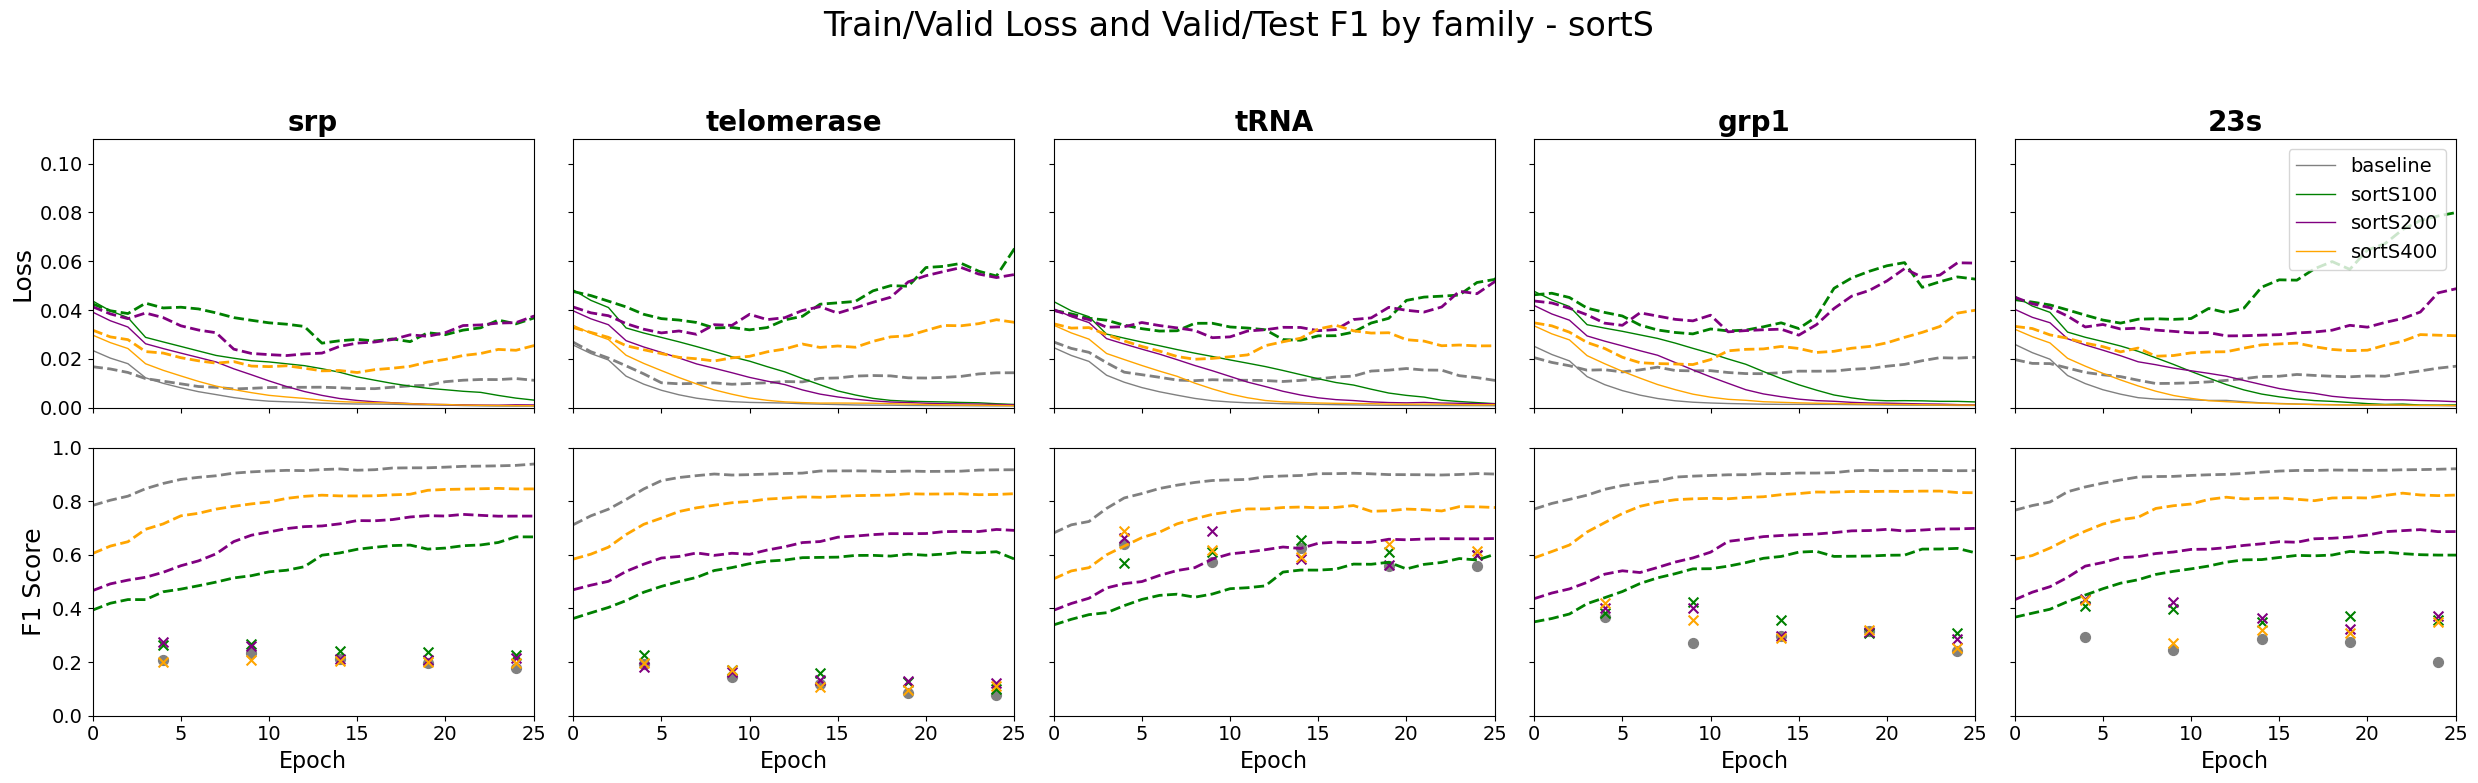

In [47]:
dataset_names = ["baseline","sortS100", "sortS200", "sortS400"]
df_list = [dfs_all[k] for k in dataset_names]
fams2 = ['srp', 'telomerase', 'tRNA', 'grp1', '23s']
plot_loss_and_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams2,
    title="Train/Valid Loss and Valid/Test F1 by family - sortS",
)

/tmp/ipykernel_331833/2509083565.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


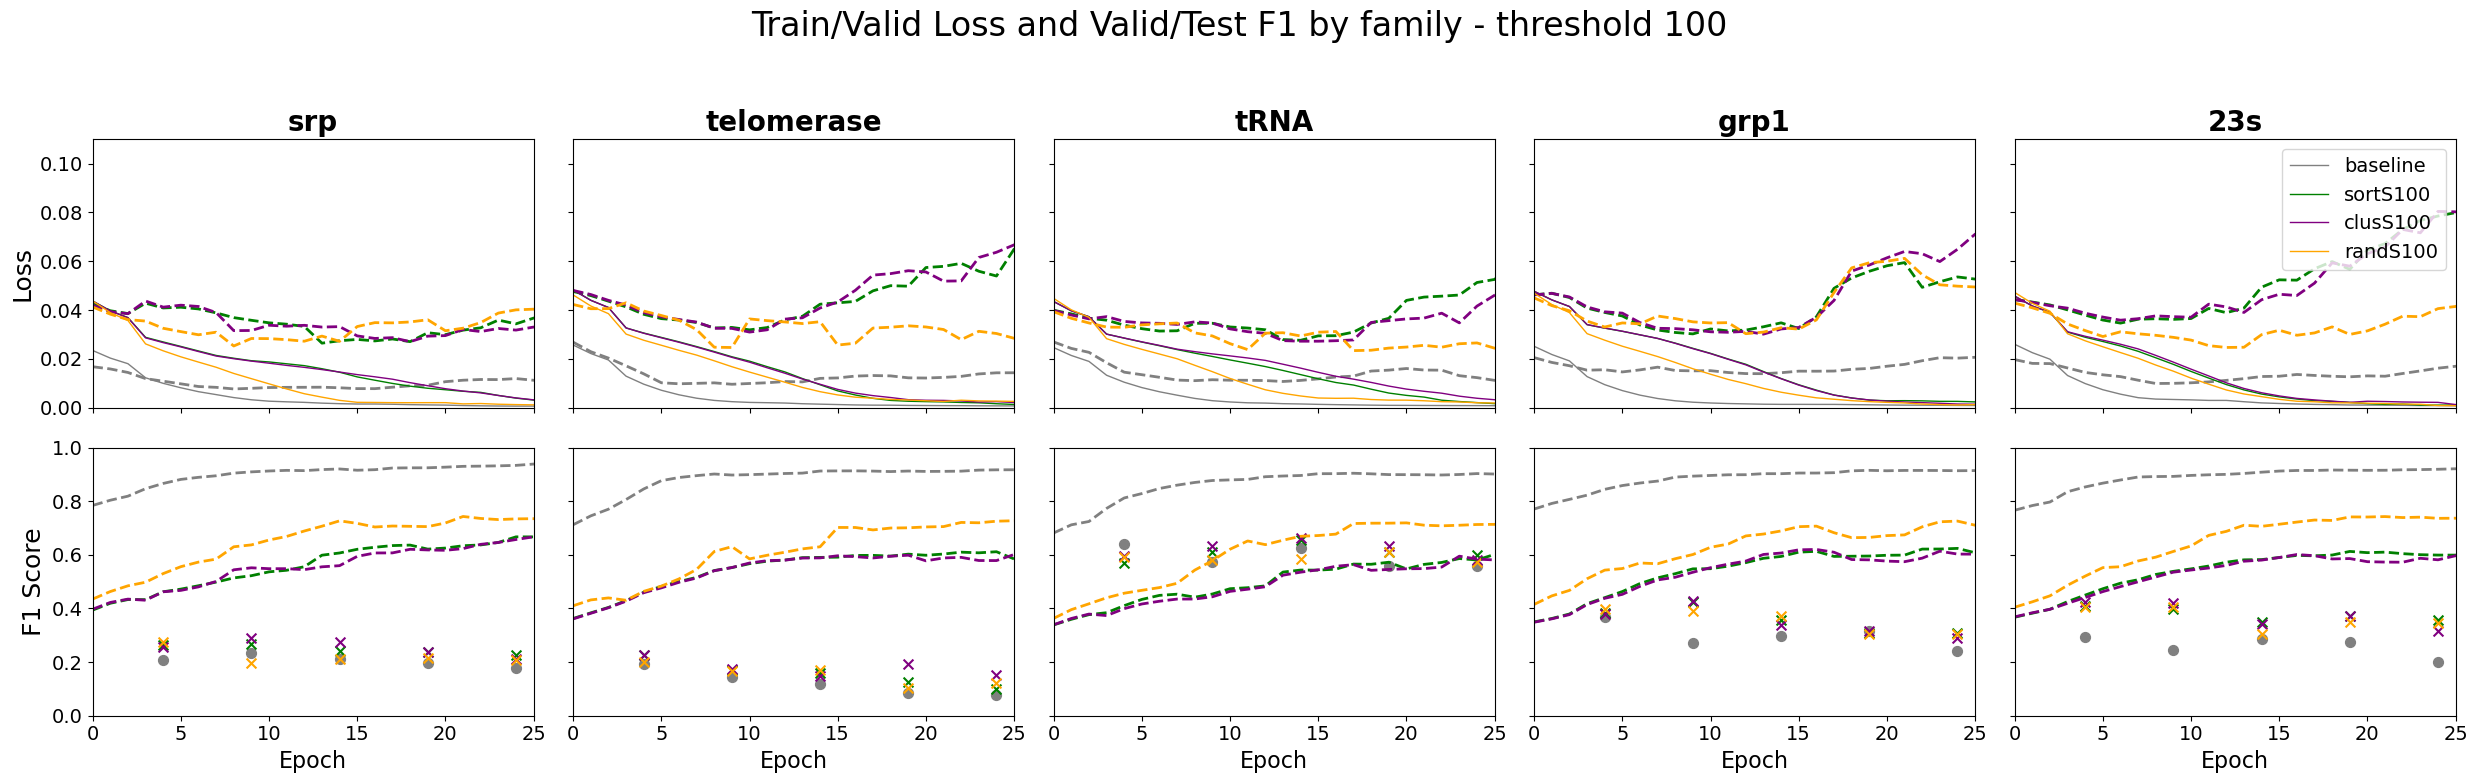

In [46]:
dataset_names = ["baseline", "sortS100", "clusS100", "randS100"]
df_list = [dfs_all[k] for k in dataset_names]
fams2 = ['srp', 'telomerase', 'tRNA', 'grp1', '23s']
plot_loss_and_f1_across_datasets(
    datasets=df_list,
    dataset_names=dataset_names,
    fams=fams2,
    title="Train/Valid Loss and Valid/Test F1 by family - threshold 100",
)